In [1]:
#attemping a half adder

I want to apply a carry and sum on this circuit, using a CNOT and CCNOT gate. I need 4 qubits for A, 2 qubits for B and 1 for carry

In [1]:
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, Reset
import matplotlib.pyplot as plt
import math
import numpy as np
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

0: 0 + 0, 1: 0 + 1, 2: 1 + 1

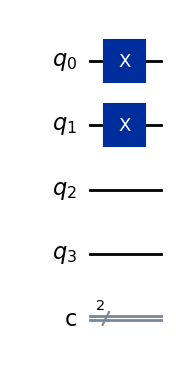

In [2]:
circ = QuantumCircuit(4,2)

#A = 1
circ.x(0)

#B = 1
circ.x(1)

circ.draw("mpl")

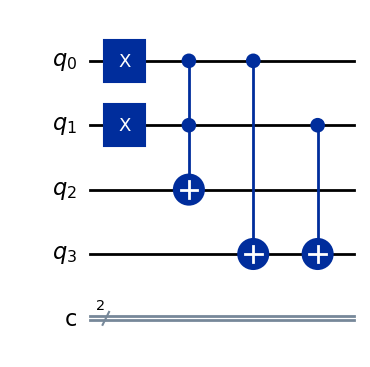

In [3]:
#carry
circ.ccx(0,1,2)
#sum
circ.cx(0,3)
circ.cx(1,3)
circ.draw('mpl')

In [4]:
circ.measure(3, 0)
circ.measure(2, 1)

Raw Qiskit output: 10
Measurement Counts: {'0111 10': 1024}


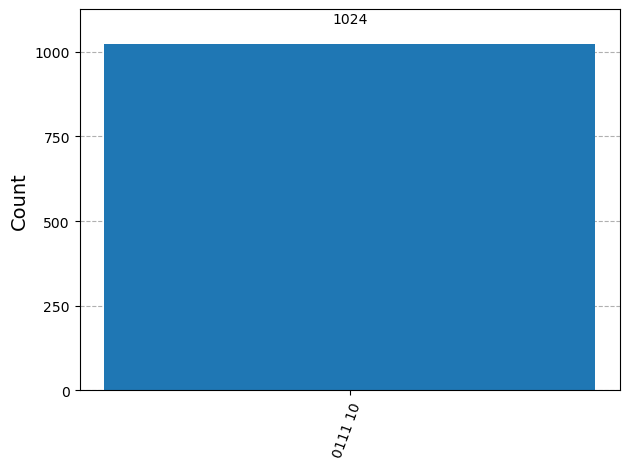

In [5]:
sim = AerSimulator()
result = sim.run(transpile(circ, sim)).result()

counts = result.get_counts()

StateV = list(counts.keys())[0]

# flip
Stateflipped = StateV[::-1]

print("Raw Qiskit output:", StateV)


qc_fin = circ.copy()
#Measurement
qc_fin.measure_all()

simulator = AerSimulator()
job = simulator.run([qc_fin])
result = job.result()
counts = result.get_counts(0)
print(f"Measurement Counts: {counts}")
plot_histogram(counts)